## Case Study — Fintech Technical Assessment

**Context:** Analysis of daily GBP → Emerging Market corridor transfer 
volumes (Apr–Dec 2023), completed as part of a Data Analyst technical 
assessment at a leading UK-based Fintech.

**Questions answered:**
1. Describe the distribution of daily transfer volumes.
2. What real-world cause explains this distribution shape?
3. What analytical implications does this distribution have?
4. Have transfer volumes changed significantly quarter to quarter?
   How do you distinguish real changes from background fluctuations?
5. Estimate total transfer volume for October 2023
   (with range and uncertainty measures).

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp
from statsmodels.formula.api import ols
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings, logging, os

# clean warnings
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').disabled = True
os.environ['PYTHONWARNINGS'] = 'ignore'

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.options.display.float_format = '{:,.2f}'.format

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Read CSV
CSV_PATH = r"\take_home_task_dataset.csv"
raw_df = pd.read_csv(CSV_PATH)
raw_df['posting_date'] = pd.to_datetime(raw_df['posting_date'])

# Save a raw copy for comparative charts
raw_volumes_global = raw_df['volume_gbp'].dropna()

# In-memory SQLite connection
conn = sqlite3.connect(":memory:")
raw_df.to_sql("transfers", conn, if_exists="replace", index=False)

print(f"Dataset loaded: {len(raw_df)} rows")
print(f"Dates: {raw_df['posting_date'].min()} → {raw_df['posting_date'].max()}")

Dataset loaded: 253 rows
Dates: 2023-04-01 00:00:00 → 2023-12-31 00:00:00


In [3]:
conn.execute("DROP TABLE IF EXISTS transfers_final")

# Complete calendar
all_dates = pd.date_range('2023-04-01', '2023-12-31', freq='D')
calendar = pd.DataFrame({'posting_date': all_dates})

# Merge with raw data (we use the global variable raw_df)
daily = calendar.merge(raw_df, on='posting_date', how='left')

# Features
daily['quarter'] = daily['posting_date'].dt.to_period('Q').astype(str)
daily['dow'] = daily['posting_date'].dt.dayofweek
daily['day_type'] = np.where(daily['dow'] <= 3, 'Mon-Thu',
                   np.where(daily['dow'] == 4, 'Friday', 'Weekend'))

# Imputation
lookup_qtr = daily[daily['volume_gbp'].notna()].groupby(['quarter', 'dow'])['volume_gbp'].mean()
historical_avg = daily[daily['volume_gbp'].notna()].groupby('dow')['volume_gbp'].mean()

def impute_pro(row):
    if pd.isna(row['volume_gbp']):
        key = (row['quarter'], row['dow'])
        if key in lookup_qtr.index:
            return lookup_qtr[key]
        return historical_avg[row['dow']]
    return row['volume_gbp']

daily['volume_gbp'] = daily.apply(impute_pro, axis=1)

# Save in SQLite
daily[['posting_date', 'volume_gbp', 'quarter', 'day_type']].to_sql(
    "transfers_final", conn, if_exists="replace", index=False
)

# Check
check = pd.read_sql("SELECT quarter, COUNT(*) as days, COUNT(CASE WHEN day_type='Mon-Thu' THEN 1 END) as mon_thu FROM transfers_final GROUP BY quarter", conn)
print("Complete series created correctly:")
print(check)

Complete series created correctly:
  quarter  days  mon_thu
0  2023Q2    91       52
1  2023Q3    92       52
2  2023Q4    92       52


In [4]:
# Summary by quarter and day type (post-imputation)
summary = pd.read_sql("""
SELECT quarter, day_type, volume_gbp
FROM transfers_final
""", conn)

summary_agg = (summary
    .groupby(['quarter', 'day_type'])
    .agg(
        n_days=('volume_gbp', 'count'),
        avg_daily_gbp=('volume_gbp', lambda x: round(x.mean(), 0)),
        median_daily_gbp=('volume_gbp', lambda x: round(x.median(), 0)),
        total_million_gbp=('volume_gbp', lambda x: round(x.sum() / 1_000_000, 2))
    )
    .reset_index()
)

order = {'Mon-Thu': 0, 'Friday': 1, 'Weekend': 2}
summary_agg = summary_agg.sort_values(
    by=['quarter', 'day_type'],
    key=lambda x: x.map(order) if x.name == 'day_type' else x
).reset_index(drop=True)

print("Summary by quarter and day type (post-imputation)")
display(summary_agg)

Summary by quarter and day type (post-imputation)


,quarter,day_type,n_days,avg_daily_gbp,median_daily_gbp,total_million_gbp
0,2023Q2,Mon-Thu,52,"309,408.00","265,023.00",16.09
1,2023Q2,Friday,13,"122,212.00","128,985.00",1.59
2,2023Q2,Weekend,26,"47,740.00",510.00,1.24
3,2023Q3,Mon-Thu,52,"258,575.00","237,693.00",13.45
4,2023Q3,Friday,13,"88,687.00","74,373.00",1.15
5,2023Q3,Weekend,27,"53,812.00","4,537.00",1.45
6,2023Q4,Mon-Thu,52,"285,370.00","281,039.00",14.84
7,2023Q4,Friday,13,"258,778.00","258,778.00",3.36
8,2023Q4,Weekend,27,"25,463.00","2,128.00",0.69


In [5]:
summary = pd.read_sql("""
SELECT day_type, volume_gbp
FROM transfers_final
""", conn)

summary_agg = (summary
    .groupby(['day_type'])
    .agg(
        n_days=('volume_gbp', 'count'),
        avg_daily_gbp=('volume_gbp', lambda x: round(x.mean(), 0)),
        median_daily_gbp=('volume_gbp', lambda x: round(x.median(), 0)),
        total_million_gbp=('volume_gbp', lambda x: round(x.sum() / 1_000_000, 2))
    )
    .reset_index()
)

order = {'Mon-Thu': 0, 'Friday': 1, 'Weekend': 2}
summary_agg = summary_agg.sort_values(
    by=['day_type'],
    key=lambda x: x.map(order) if x.name == 'day_type' else x
).reset_index(drop=True)

print("Summary by day type (post-imputation)")
display(summary_agg)

Summary by day type (post-imputation)


,day_type,n_days,avg_daily_gbp,median_daily_gbp,total_million_gbp
0,Mon-Thu,156,"284,451.00","267,836.00",44.37
1,Friday,39,"156,559.00","128,985.00",6.11
2,Weekend,80,"42,271.00","2,244.00",3.38


In [6]:
# Global statistics
desc = pd.read_sql_query("SELECT volume_gbp FROM transfers_final", conn)['volume_gbp'].describe()
skew = pd.read_sql_query("SELECT volume_gbp FROM transfers_final", conn)['volume_gbp'].skew()
print(f"\nSkewness: {skew:.2f}")


Skewness: 1.07


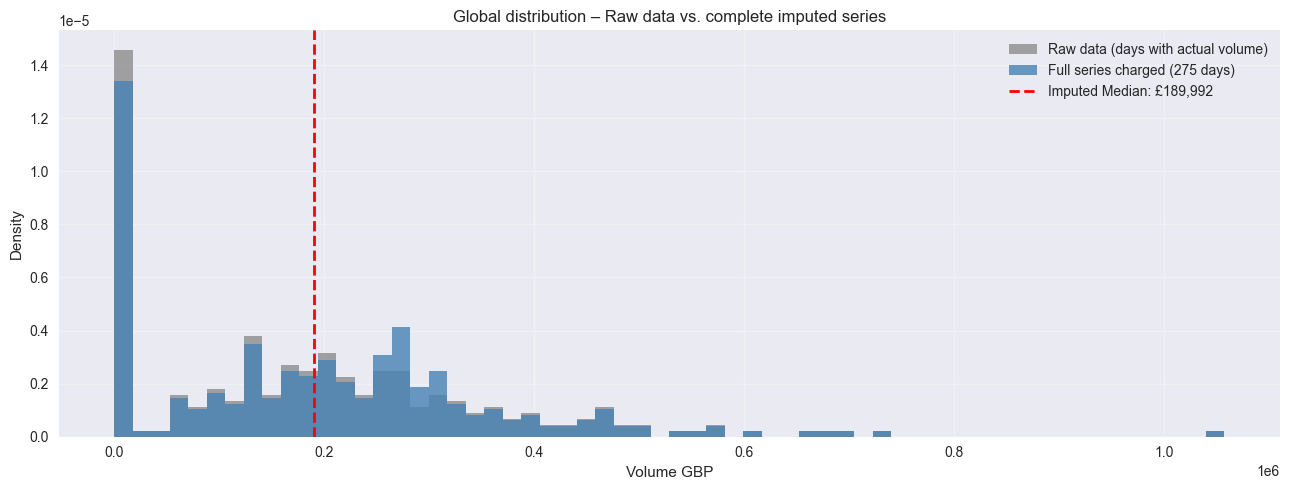

In [7]:
# Global distribution: crude vs. imputed
imputed = pd.read_sql("SELECT volume_gbp FROM transfers_final", conn)['volume_gbp']

plt.figure(figsize=(13, 5))
plt.hist(raw_volumes_global, bins=60, alpha=0.7, color='gray', 
         label='Raw data (days with actual volume)', density=True)
plt.hist(imputed, bins=60, alpha=0.8, color='steelblue', 
         label='Full series charged (275 days)', density=True)
plt.axvline(imputed.median(), color='red', linestyle='--', linewidth=2,
            label=f'Imputed Median: £{imputed.median():,.0f}')
plt.xlabel('Volume GBP')
plt.ylabel('Density')
plt.title('Global distribution – Raw data vs. complete imputed series')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

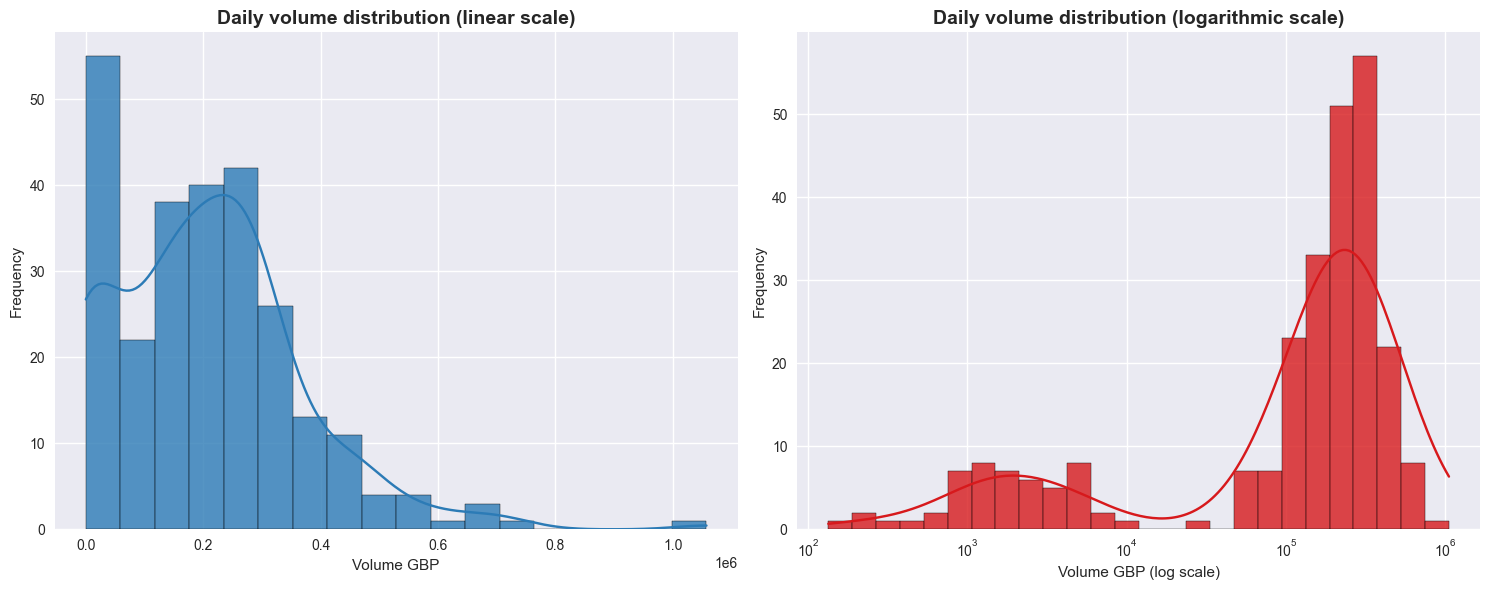

In [8]:
# Linear + log histograms (unstratified)
volumes = pd.read_sql("SELECT volume_gbp FROM transfers_final", conn)
volumes_pos = volumes[volumes['volume_gbp'] > 100]  # avoid noise at 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Linear
sns.histplot(data=volumes_pos, x='volume_gbp', kde=True, ax=ax1, color='#2c7bb6', alpha=0.8)
ax1.set_title('Daily volume distribution (linear scale)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Volume GBP')
ax1.set_ylabel('Frequency')

# Log
sns.histplot(data=volumes_pos, x='volume_gbp', kde=True, ax=ax2, color='#d7191c', alpha=0.8, log_scale=(True, False))
ax2.set_title('Daily volume distribution (logarithmic scale)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Volume GBP (log scale)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

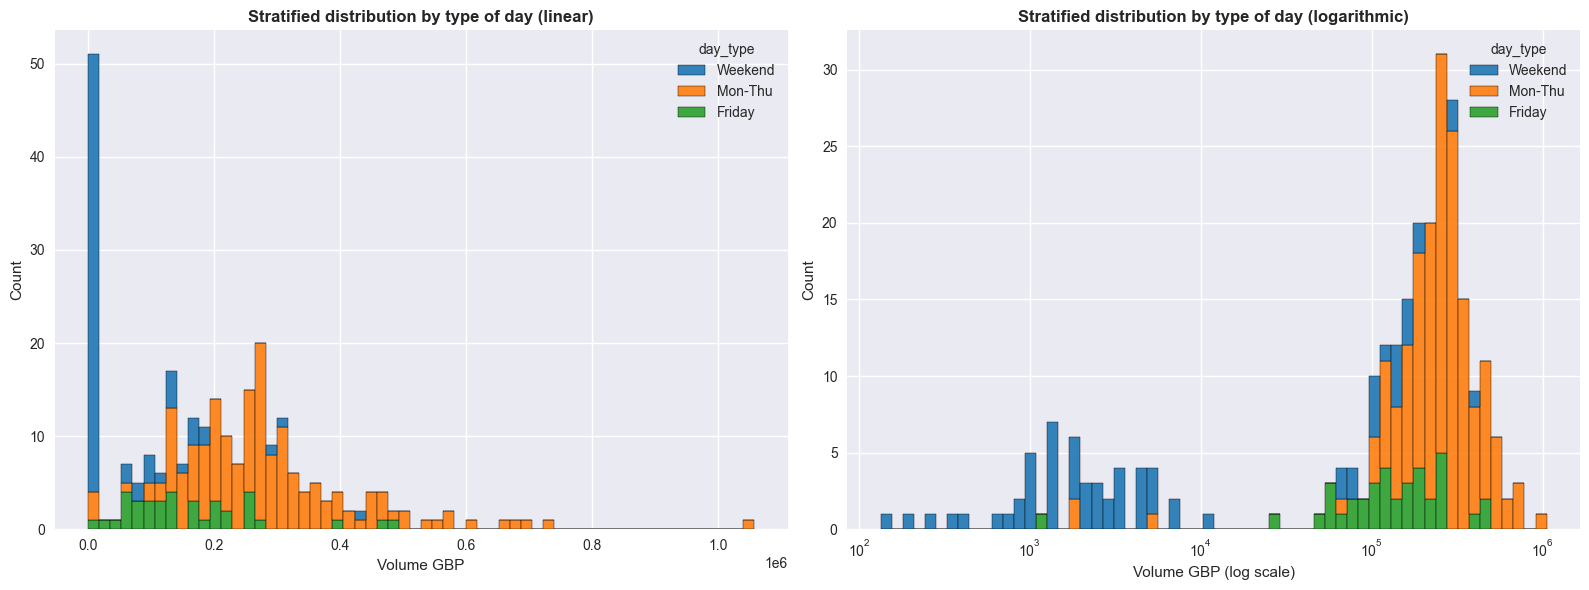

In [9]:
# Histograms stratified by day_type
volumes_full = pd.read_sql("SELECT volume_gbp, day_type FROM transfers_final", conn)
volumes_pos = volumes_full[volumes_full['volume_gbp'] > 100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=volumes_pos, x='volume_gbp', hue='day_type', palette='tab10', 
             multiple='stack', bins=60, ax=ax1, alpha=0.9)
ax1.set_title('Stratified distribution by type of day (linear)', fontweight='bold')
ax1.set_xlabel('Volume GBP')

sns.histplot(data=volumes_pos, x='volume_gbp', hue='day_type', palette='tab10', 
             multiple='stack', bins=60, ax=ax2, alpha=0.9, log_scale=(True, False))
ax2.set_title('Stratified distribution by type of day (logarithmic)', fontweight='bold')
ax2.set_xlabel('Volume GBP (log scale)')

plt.tight_layout()
plt.show()

In [20]:
import diptest

data = volumes['volume_gbp'].values
dip, pval = diptest.diptest(data)
print(f"Dip test: dip = {dip:.4f}, p-value = {pval:.3f}")
print("This test is very powerful and detects any deviation from unimodal distribution.")
print("\n")

print("At first glance, the distribution appears to be bimodal and is supported by the dip test. However, we are faced with")
print("the overlap of three regimes with very different averages. When stratified by day_type, the bimodality disappears.")

Dip test: dip = 0.0619, p-value = 0.000
This test is very powerful and detects any deviation from unimodal distribution.


At first glance, the distribution appears to be bimodal and is supported by the dip test. However, we are faced with
the overlap of three regimes with very different averages. When stratified by day_type, the bimodality disappears.


In [11]:
# VOLUME EVOLUTION ON WORKING DAYS (Mon–Thu)
# Complete analysis Q2 → Q3 → Q4 (regime explaining >82% of volume)

mon_thu = pd.read_sql("""
    SELECT volume_gbp, quarter 
    FROM transfers_final 
    WHERE day_type = 'Mon-Thu'
""", conn)

# quarters
q2 = mon_thu[mon_thu['quarter'] == '2023Q2']['volume_gbp']
q3 = mon_thu[mon_thu['quarter'] == '2023Q3']['volume_gbp']
q4 = mon_thu[mon_thu['quarter'] == '2023Q4']['volume_gbp']

print(f"Number of days Mon–Thu per quarter:")
print(f"  Q2: {len(q2):2d} days → median £{q2.median():,.0f}")
print(f"  Q3: {len(q3):2d} days → median £{q3.median():,.0f} ({(q3.median()/q2.median()-1)*100:+5.2f}% vs Q2)")
print(f"  Q4: {len(q4):2d} days → median £{q4.median():,.0f} ({(q4.median()/q3.median()-1)*100:+5.2f}% vs Q3)\n")

# Overall test: are there any differences between the three quarters?
# Use kruskal_wallis (nonparametric equivalent of ANOVA)
stat, p_global = stats.kruskal(q2, q3, q4)
print(f"Kruskal-Wallis (3 groups): H = {stat:.2f}, p = {p_global:.3f}")
if p_global < 0.1:
    print("   → Detectable overall trend (p<0.1)")
else:
    print("   → There is no strong evidence of structural change between quarters.")
    
## Krukal-Wallis tells me if at least one group is different from the others, but I don't know which one(s).
## Post-hoc tells us exactly between which pairs of quarters there are differences.

# Post-hoc pairwise with Bonferroni correction
posthoc = sp.posthoc_dunn(mon_thu, val_col='volume_gbp', group_col='quarter', p_adjust='bonferroni')

print(f"\nPost-hoc Dunn (Bonferroni):")
print(posthoc.round(3))

# Summary
print(f"\nClear interpretive summary:")
print(f"   • Q2 → Q3: decline (−10.31%), not significant (p={posthoc.loc['2023Q2','2023Q3']:.3f})")
print(f"   • Q3 → Q4: recovery (+18.24%), expected direction for the end of the year, not yet significant (p={posthoc.loc['2023Q3','2023Q4']:.3f})")

print(f"\nConclusion for forecasting:")
print(f"   → There is no statistically significant structural change.")
print(f"   → But there was a positive trend in Q4 in line with year-end patterns.")
print(f"   → Justify including a moderate positive linear trend in the models.")

Number of days Mon–Thu per quarter:
  Q2: 52 days → median £265,023
  Q3: 52 days → median £237,693 (-10.31% vs Q2)
  Q4: 52 days → median £281,039 (+18.24% vs Q3)

Kruskal-Wallis (3 groups): H = 4.24, p = 0.120
   → There is no strong evidence of structural change between quarters.

Post-hoc Dunn (Bonferroni):
        2023Q2  2023Q3  2023Q4
2023Q2    1.00    0.48    1.00
2023Q3    0.48    1.00    0.14
2023Q4    1.00    0.14    1.00

Clear interpretive summary:
   • Q2 → Q3: decline (−10.31%), not significant (p=0.479)
   • Q3 → Q4: recovery (+18.24%), expected direction for the end of the year, not yet significant (p=0.135)

Conclusion for forecasting:
   → There is no statistically significant structural change.
   → But there was a positive trend in Q4 in line with year-end patterns.
   → Justify including a moderate positive linear trend in the models.


In [12]:
# OCTOBER 2023 FORECAST

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

# October 2023 calendar
oct_dates = pd.date_range('2023-10-01', '2023-10-31')
oct_df = pd.DataFrame({'date': oct_dates})
oct_df['dow'] = oct_df['date'].dt.dayofweek
oct_df['day_type'] = np.where(oct_df['dow'] <= 3, 'Mon-Thu',
                    np.where(oct_df['dow'] == 4, 'Friday', 'Weekend'))

# Stratified average
means = pd.read_sql("""
    SELECT day_type, AVG(volume_gbp) AS avg_vol 
    FROM transfers_final 
    GROUP BY day_type
""", conn)

mon_thu_avg = means.loc[means['day_type']=='Mon-Thu', 'avg_vol'].iloc[0]
fri_avg     = means.loc[means['day_type']=='Friday', 'avg_vol'].iloc[0]
weekend_avg = means.loc[means['day_type']=='Weekend', 'avg_vol'].iloc[0]

est1 = mon_thu_avg * 9 + fri_avg * 4 + weekend_avg * 8
print(f"1. Stratified average: £{est1:,.0f}")

# Linear regression
daily_reg = pd.read_sql("SELECT posting_date, volume_gbp, day_type FROM transfers_final", conn)
daily_reg['trend'] = np.arange(1, len(daily_reg) + 1)

model = ols('volume_gbp ~ trend + C(day_type)', data=daily_reg).fit(cov_type='HC3')

oct_for_pred = oct_df.copy()
oct_for_pred['trend'] = np.arange(len(daily_reg) + 1, len(daily_reg) + 32)

est2 = model.predict(oct_for_pred).sum()
print(f"2. Linear regression (trend + day): £{est2:,.0f}")

# Holt-Winters
ts = pd.read_sql("SELECT posting_date, volume_gbp FROM transfers_final ORDER BY posting_date", conn)
ts = ts.set_index('posting_date')['volume_gbp']

hw = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=7).fit()
hw_forecast = hw.forecast(31)
est3 = hw_forecast.sum()
print(f"3. Holt-Winters: £{est3:,.0f}")

# CONFIDENCE INTERVALS (BOOTSTRAP) FOR HOLT–WINTERS

h = 31
n_boot = 1500

# residuals
fitted = hw.fittedvalues
residuals = (ts.values - fitted.values)
residuals = residuals[~np.isnan(residuals)]

# bootstrap
rng = np.random.default_rng(42)
boot_forecasts = np.empty((n_boot, h))

base = hw_forecast.values

for i in range(n_boot):
    sampled = rng.choice(residuals, size=h, replace=True)
    boot_forecasts[i, :] = base + sampled

# CI for the GRAND TOTAL for October
total_boot = boot_forecasts.sum(axis=1)
lower_total, upper_total = np.percentile(total_boot, [2.5, 97.5])

print(f"   Holt-Winters 95% CI (total October): £{lower_total:,.0f} – £{upper_total:,.0f}")

ensamble = np.mean([est1, est2, est3])
print(f"\nFINAL RECOMMENDATION FOR TREASURY")
print(f"   Estimate October 2023: £{ensamble:,.0f}")
print(f"   Operating range (based on 3 methods): £{min(est1,est2,est3):,.0f} – £{max(est1,est2,est3):,.0f}")
print(f"   Holt-Winters interval (statistical uncertainty): £{lower_total:,.0f} – £{upper_total:,.0f}")


1. Stratified average: £3,524,462
2. Linear regression (trend + day): £5,950,109
3. Holt-Winters: £6,786,712
   Holt-Winters 95% CI (total October): £5,335,732 – £7,914,028

FINAL RECOMMENDATION FOR TREASURY
   Estimate October 2023: £5,420,428
   Operating range (based on 3 methods): £3,524,462 – £6,786,712
   Holt-Winters interval (statistical uncertainty): £5,335,732 – £7,914,028


In [13]:
# ADD COLUMN ‘dow’ TO transfers_final

# Recreate transfers_final with the dow column included
daily_full = pd.read_sql("SELECT * FROM transfers_final", conn)
daily_full['posting_date'] = pd.to_datetime(daily_full['posting_date'])
daily_full['dow'] = daily_full['posting_date'].dt.dayofweek  # 0=lunes ... 6=domingo

# Replace the table in SQLite
daily_full.to_sql("transfers_final", conn, if_exists="replace", index=False)

print("Column ‘dow’ successfully added to transfers_final")
print("Current columns:", daily_full.columns.tolist())

Column ‘dow’ successfully added to transfers_final
Current columns: ['posting_date', 'volume_gbp', 'quarter', 'day_type', 'dow']


In [17]:
# GRANULAR ANALYSIS
import pymannkendall as mk

# 1. Regression with dummies by specific days
daily_reg_granular = pd.read_sql("""
    SELECT posting_date, volume_gbp, dow 
    FROM transfers_final 
    ORDER BY posting_date
""", conn)

daily_reg_granular['trend'] = np.arange(1, len(daily_reg_granular)+1)

model_granular = ols('volume_gbp ~ trend + C(dow)', data=daily_reg_granular).fit(cov_type='HC3')

print("Key coefficients (trend + days):")
print(model_granular.params[['trend', 'C(dow)[T.1]', 'C(dow)[T.2]', 'C(dow)[T.3]', 'C(dow)[T.4]', 'C(dow)[T.5]', 'C(dow)[T.6]']])

# October forecast
oct_granular = oct_df.copy()
oct_granular['trend'] = np.arange(len(daily_reg_granular)+1, len(daily_reg_granular)+32)
est_granular = model_granular.predict(oct_granular).sum()
print(f"\nOctober forecast (7 dummies): £{est_granular:,.0f}")

# 2. Mann-Kendall Friday y Weekend
friday_vol = pd.read_sql("SELECT volume_gbp FROM transfers_final WHERE day_type='Friday' ORDER BY posting_date", conn)['volume_gbp']
weekend_vol = pd.read_sql("SELECT volume_gbp FROM transfers_final WHERE day_type='Weekend' ORDER BY posting_date", conn)['volume_gbp']

mk_f = mk.original_test(friday_vol)
mk_w = mk.original_test(weekend_vol)

print(f"\nMann-Kendall Friday → tau = {mk_f.Tau:.3f}, p = {mk_f.p:.3f}")
print(f"Mann-Kendall Weekend → tau = {mk_w.Tau:.3f}, p = {mk_w.p:.3f}")

Key coefficients (trend + days):
trend              -35.63
C(dow)[T.1]     84,081.27
C(dow)[T.2]     -8,416.29
C(dow)[T.3]    -44,661.60
C(dow)[T.4]   -120,052.04
C(dow)[T.5]   -274,734.20
C(dow)[T.6]   -194,088.82
dtype: float64

October forecast (7 dummies): £6,066,687

Mann-Kendall Friday → tau = 0.224, p = 0.046
Mann-Kendall Weekend → tau = 0.049, p = 0.519


---
*Completed as part of a technical assessment at a leading UK-based Fintech. 
All data was provided by the company. Methodology and conclusions are entirely my own.*